In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing, metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import lightgbm as lgb

data = pd.read_csv('nasa.csv')


In [4]:
# Remove unnecessary ID columns and cols with low variance/too many missing values
cols_to_drop = ['id', 'pdes', 'name', 'prefix', 'equinox', 'diameter', 'albedo', 'diameter_sigma']
data1 = data.drop(cols_to_drop, axis=1)
# Remove rows with missing 'pha' or other key fields
data1 = data1[data1['pha'].notna()]
data1 = data1[data1['H'].notna()]
data1 = data1[data1['sigma_ad'].notna()]
data1 = data1[data1['ma'].notna()]


In [5]:
# Convert categorical flags to category dtype
for col in ['neo', 'pha', 'class']:
    data1[col] = data1[col].astype('category')

# One-hot encode 'neo', 'class', 'orbit_id'
data2 = pd.get_dummies(data1, columns=['neo', 'class', 'orbit_id'])


In [6]:
# Replace rare orbit_ids with 'other'
orbit_counts = data1['orbit_id'].value_counts()
rare_orbits = orbit_counts[orbit_counts < 10].index
data1.loc[data1['orbit_id'].isin(rare_orbits), 'orbit_id'] = 'other'

# Drop orbit_id, sigma_ma, sigma_tp after one-hot encoding
data2.drop(['orbit_id_other', 'sigma_ma', 'sigma_tp'], axis=1, inplace=True, errors='ignore')


In [7]:
# Normalize continuous features
num_cols = data2.select_dtypes(include=[np.number]).columns.tolist()
scaler = preprocessing.MinMaxScaler()
data2[num_cols] = scaler.fit_transform(data2[num_cols])


In [8]:
# Set up features and labels
X = data2.drop(['spkid', 'full_name', 'pha'], axis=1)
y = data2['pha']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1501)

print("Before OverSampling, N:", sum(y_train == 'N'))
print("Before OverSampling, Y:", sum(y_train == 'Y'))

# Balance classes using SMOTE
sm = SMOTE(random_state=12)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

print("After OverSampling, N:", sum(y_train_res == 'N'))
print("After OverSampling, Y:", sum(y_train_res == 'Y'))


Before OverSampling, N: 4332
Before OverSampling, Y: 20
After OverSampling, N: 4332
After OverSampling, Y: 4332


In [9]:
# Model Training and Evaluation Functions
def metricCalculation(y_test, pred):
    print('Precision (macro):', round(metrics.precision_score(y_test, pred, average="macro"), 2))
    print('Recall (macro):', round(metrics.recall_score(y_test, pred, average="macro"), 2))
    print('Accuracy:', round(metrics.accuracy_score(y_test, pred), 4))
    print('F1 (macro):', round(metrics.f1_score(y_test, pred, average="macro"), 2))
    print('Confusion Matrix:\n', metrics.confusion_matrix(y_test, pred))


In [10]:
# Logistic Regression Model
logreg = LogisticRegression(max_iter=10000)
logreg.fit(x_train_res, y_train_res)
lr_pred = logreg.predict(x_test)
metricCalculation(y_test, lr_pred)


Precision (macro): 0.7
Recall (macro): 0.95
Accuracy: 0.9925
F1 (macro): 0.78
Confusion Matrix:
 [[1843   13]
 [   1    9]]


In [11]:
# Random Forest Model & Feature Importance
rf = RandomForestClassifier(n_estimators=150, random_state=1551)
rf.fit(x_train_res, y_train_res)
rf_pred = rf.predict(x_test)
metricCalculation(y_test, rf_pred)

# Feature importance
feat_imp = pd.DataFrame(rf.feature_importances_, index=x_train_res.columns, columns=['Importance'])
print(feat_imp.sort_values(by='Importance', ascending=False).head(10))


Precision (macro): 0.95
Recall (macro): 0.95
Accuracy: 0.9989
F1 (macro): 0.95
Confusion Matrix:
 [[1855    1]
 [   1    9]]
           Importance
moid_ld      0.125543
moid         0.091846
class_APO    0.078144
e            0.062549
neo_Y        0.061040
neo_N        0.059693
q            0.057248
class_MBA    0.055090
H            0.053761
n            0.043466


In [12]:
# LightGBM
# Encode y for LGBM
y_train_num = (y_train_res == 'Y').astype(int)
y_test_num = (y_test == 'Y').astype(int)

train_data = lgb.Dataset(x_train_res, label=y_train_num)
param = {'num_leaves': 150, 'nrounds': 350, 'max_depth': 25, 'learning_rate': 0.01, 'max_bin': 500}
lgbm = lgb.train(param, train_data)
lgbm_pred = (lgbm.predict(x_test) >= 0.5).astype(int)
metricCalculation(y_test_num, lgbm_pred)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13521
[LightGBM] [Info] Number of data points in the train set: 8664, number of used features: 78
[LightGBM] [Info] Start training from score 0.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

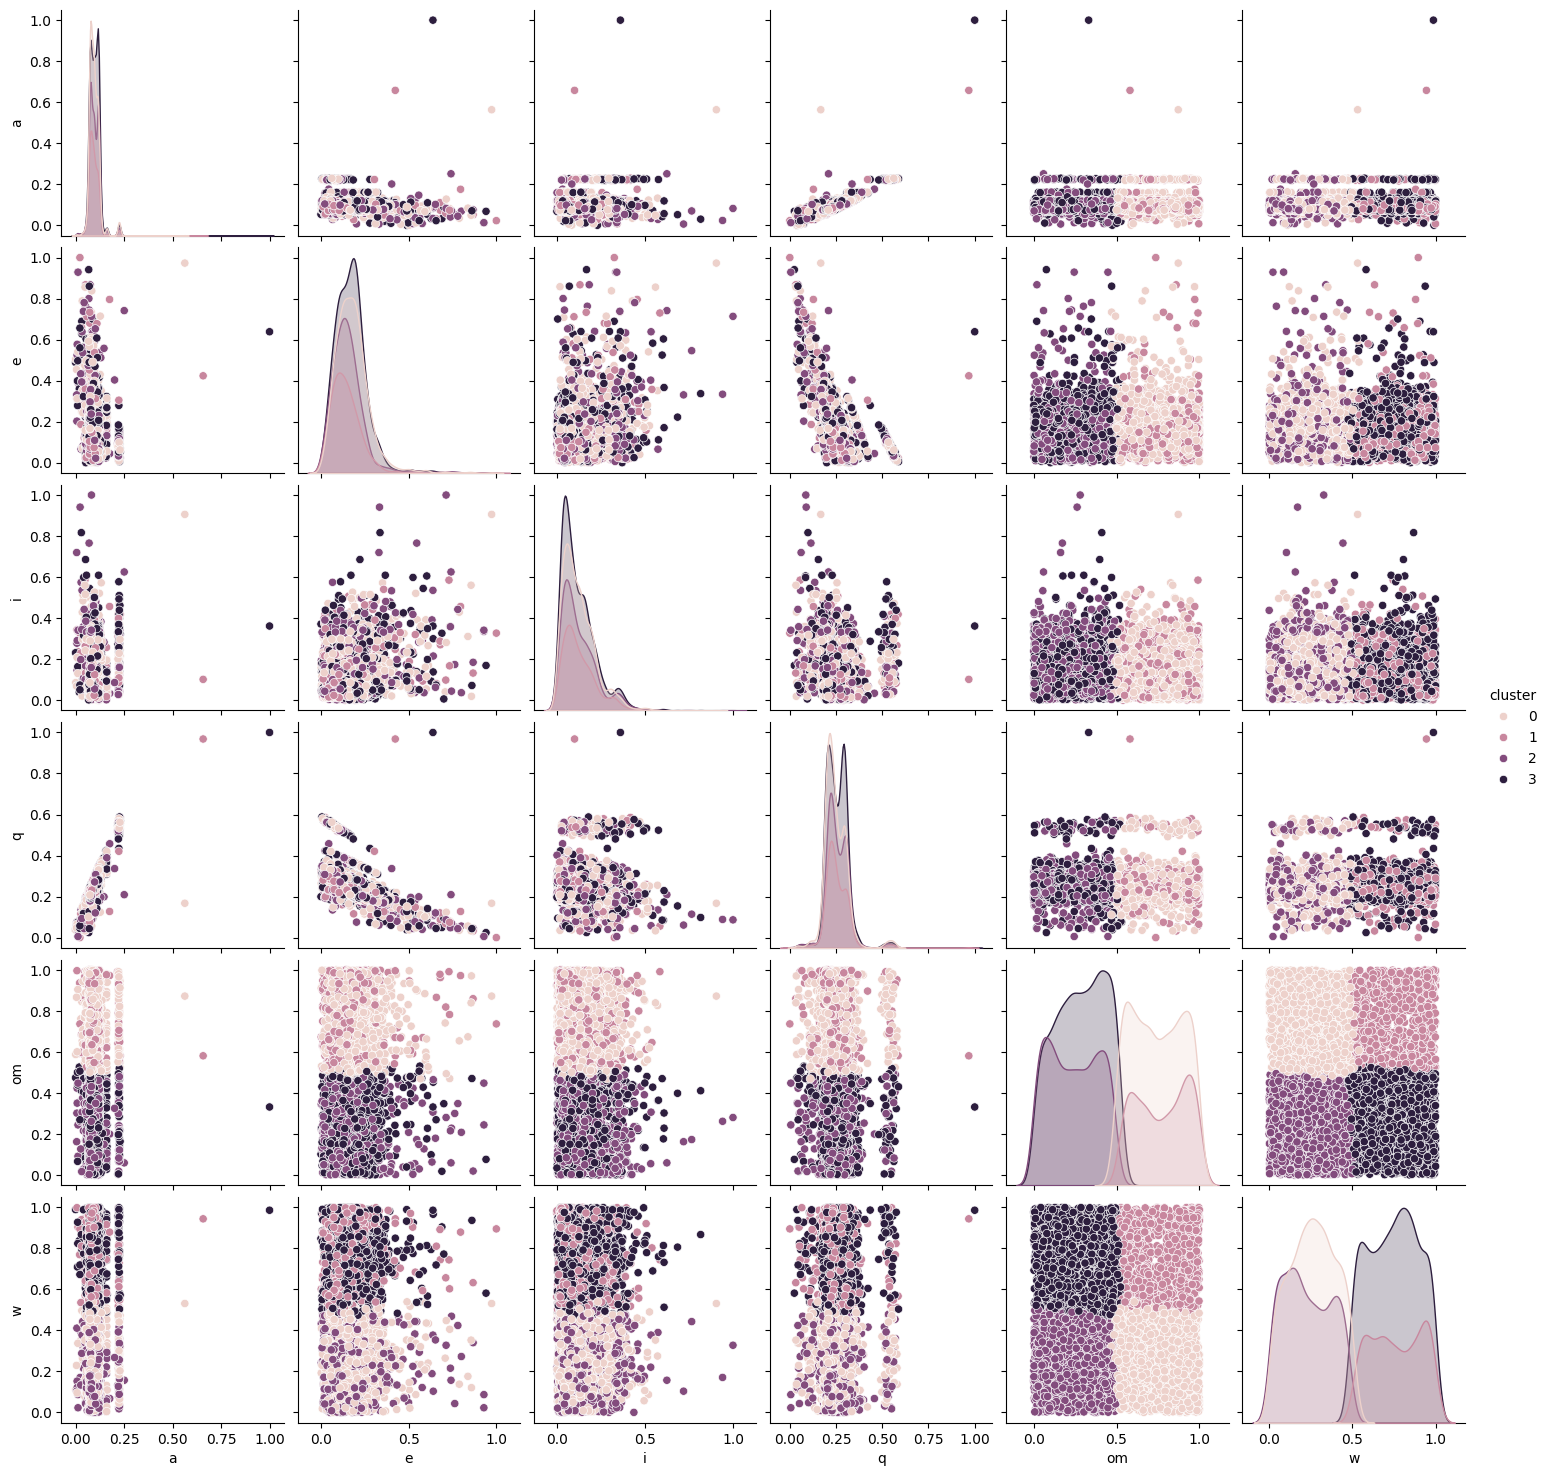

In [13]:
# Addtion 1: K-Means CLustering
from sklearn.cluster import KMeans
# Use only orbital elements for clustering
orbital_cols = ['a','e','i','q','om','w']
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(data2[orbital_cols])
data2['cluster'] = kmeans.labels_

sns.pairplot(data2, vars=orbital_cols, hue='cluster')
plt.show()


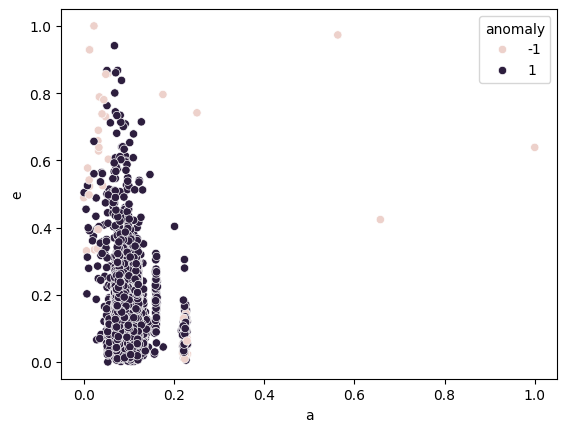

In [14]:
# Addtion 2: Isolation Forest for Anomaly Detection
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.01, random_state=42)
orbit_cols_data = data2[orbital_cols]
outliers = iso.fit_predict(orbit_cols_data)
data2['anomaly'] = outliers
# Plot anomalies
sns.scatterplot(data=orbit_cols_data, x='a', y='e', hue=data2['anomaly'])
plt.show()


R2 Score: 0.9998165883990223


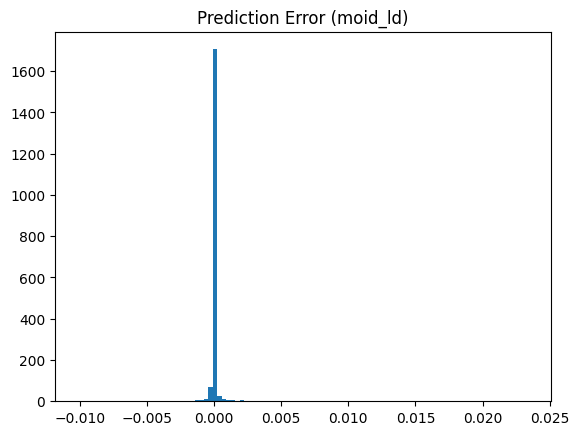

In [15]:
# Addtion 3: Regression to predict moid_id
from sklearn.ensemble import RandomForestRegressor
target_reg = 'moid_ld'
reg_X = data2.drop(['spkid', 'full_name', 'moid_ld', 'pha'], axis=1)
reg_y = data2['moid_ld']
xtr, xte, ytr, yte = train_test_split(reg_X, reg_y, test_size=0.3, random_state=42)
reg = RandomForestRegressor(n_estimators=150, random_state=42)
reg.fit(xtr, ytr)
y_pred = reg.predict(xte)
print('R2 Score:', metrics.r2_score(yte, y_pred))
plt.hist(yte - y_pred, bins=100)
plt.title('Prediction Error (moid_ld)')
plt.show()


In [18]:
import pickle
# !!! Replace 'lgbm_final_model' if your variable has a different name !!!
lgbm_final_model = lgbm # Rename for clarity, though not strictly required
with open('asteroid_model.pkl', 'wb') as f:
    pickle.dump(lgbm_final_model, f)